In [9]:
import os, glob, tarfile, zipfile, re, time
import numpy as np, torch, torch.nn as nn, torch.nn.functional as F
import pandas as pd, matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
from scipy.spatial import ConvexHull, Delaunay

TAR_DIR  = os.path.expanduser('~/scratch')                    # folder holding Force.zip, moshpp.zip and smplh.tar.xz
WORK_DIR = os.path.expanduser('~/scratch/dynamics_project')   # cache and results
PREV_DIR = os.path.expanduser('~/scratch/torque_project')     # GroundLink and SMPL-H extracted there earlier are reused
TRACKER_CKPT = os.path.expanduser('~/scratch/tracking_project/results/t3d_offline.pt')   # optional, section 5 only

FPS, GL_CUT, G_ACC, MU_FRICTION, SEED = 30, 6.0, 9.81, 0.8, 0
GV = np.array([0, 0, -G_ACC])
dev = 'cuda' if torch.cuda.is_available() else 'cpu'
os.makedirs(f'{WORK_DIR}/results', exist_ok=True)
for sub in ('smplh', 'groundlink'):                   # reuse earlier extractions through a link
    if not os.path.exists(os.path.join(WORK_DIR, sub)) and os.path.isdir(os.path.join(PREV_DIR, sub)): os.symlink(os.path.join(PREV_DIR, sub), os.path.join(WORK_DIR, sub))
print(dev, torch.cuda.get_device_name(0) if dev == 'cuda' else '')

cuda NVIDIA A100-SXM4-40GB MIG 3g.20gb


In [10]:
SMPLH_DIR = os.path.join(WORK_DIR, 'smplh')
if not glob.glob(SMPLH_DIR + '/**/model.npz', recursive=True):
    with tarfile.open(os.path.join(TAR_DIR, 'smplh.tar.xz'), 'r:xz') as tf: tf.extractall(SMPLH_DIR)
MODEL_PATHS = {os.path.basename(os.path.dirname(p)): p for p in glob.glob(SMPLH_DIR + '/**/model.npz', recursive=True)}

def aa2mat(aa):                                   # axis-angle (...,3) -> rotation matrices (...,3,3)
    ang = aa.norm(dim=-1, keepdim=True).clamp_min(1e-8)
    x, y, z = (aa / ang).unbind(-1); zero = torch.zeros_like(x)
    K = torch.stack([zero, -z, y, z, zero, -x, -y, x, zero], -1).view(*aa.shape[:-1], 3, 3)
    s, c = ang.sin()[..., None], ang.cos()[..., None]
    return torch.eye(3, device=aa.device) + s * K + (1 - c) * (K @ K)

class SMPLH:
    def __init__(self, path, n_betas=16):
        m = np.load(path, allow_pickle=True)
        dense = lambda a: np.asarray(a.item().todense()) if a.dtype == object else np.asarray(a)
        f32 = lambda a: torch.tensor(dense(a), dtype=torch.float32, device=dev)
        self.vt, self.sd, self.pd = f32(m['v_template']), f32(m['shapedirs'])[..., :n_betas], f32(m['posedirs'])
        self.Jr, self.W = f32(m['J_regressor']), f32(m['weights'])
        par = m['kintree_table'][0].astype(np.int64); par[0] = -1; self.parents = par.tolist(); self.nj = len(par)
        assert self.pd.shape[-1] == (self.nj - 1) * 9 and self.Jr.shape == (self.nj, len(self.vt)) and self.W.shape == (len(self.vt), self.nj)
        assert all(p < i for i, p in enumerate(self.parents)), 'parents must precede children'

    def __call__(self, poses, betas, trans, v_idx=None):
        """poses (B, nj*3) axis-angle, betas (n,), trans (B,3) -> joints (B,nj,3), vertices (B,len(v_idx),3)"""
        B = len(poses); nb = min(len(betas), self.sd.shape[-1])
        v_shaped = self.vt + self.sd[..., :nb] @ betas[:nb]                     # body shape
        J = self.Jr @ v_shaped                                                  # rest joints of this body
        R = aa2mat(poses.view(B, self.nj, 3))
        G, P = [R[:, 0]], [J[0].expand(B, 3)]                                   # kinematic chain
        for i in range(1, self.nj):
            p = self.parents[i]
            G.append(G[p] @ R[:, i]); P.append(P[p] + (G[p] @ (J[i] - J[p])[:, None]).squeeze(-1))
        G, P = torch.stack(G, 1), torch.stack(P, 1)
        if v_idx is None: v_idx = torch.arange(len(self.vt), device=dev)
        feat = (R[:, 1:] - torch.eye(3, device=dev)).reshape(B, -1)             # pose blend shapes
        v_posed = v_shaped[v_idx] + (self.pd[v_idx] @ feat.T).permute(2, 0, 1)
        t = P - (G @ J[None, :, :, None]).squeeze(-1)                           # linear blend skinning
        W = self.W[v_idx]
        Rv, tv = torch.einsum('vj,bjmn->bvmn', W, G), torch.einsum('vj,bjm->bvm', W, t)
        verts = (Rv @ v_posed[..., None]).squeeze(-1) + tv
        return P + trans[:, None], verts + trans[:, None]

MODELS = {g: SMPLH(p) for g, p in MODEL_PATHS.items()}
REF = MODELS.get('neutral', next(iter(MODELS.values())))
NP_PATCH, NC = 20, 4                                   # sole contact points: L heel, L toe, R heel, R toe (20 lowest vertices each)
def sole_patches(model, n=NP_PATCH):
    J = model.Jr @ model.vt; dom = model.W.argmax(1); y, z = model.vt[:, 1], model.vt[:, 2]   # rest pose: y up, z forward
    out = []
    for ankle, toe in [(7, 10), (8, 11)]:
        heel = torch.where((dom == ankle) & (z < J[ankle, 2]))[0]; fore = torch.where(dom == toe)[0]
        for idx in (heel, fore):
            assert len(idx) >= n, 'too few candidate vertices for a sole patch'
            out.append(idx[y[idx].argsort()[:n]])
    return torch.cat(out)
PATCH = sole_patches(REF)
def parse_gender(d):
    g = d['gender'].item() if d['gender'].shape == () else d['gender']
    return g.decode() if isinstance(g, bytes) else str(g)
_j, _v = REF(torch.zeros(1, REF.nj * 3, device=dev), torch.zeros(16, device=dev), torch.zeros(1, 3, device=dev))
assert (_v[0] - REF.vt).abs().max() < 1e-4, 'zero pose does not reproduce the template'
print({g: (len(m.vt), m.nj) for g, m in MODELS.items()}, '(vertices, joints) | template height %.2f m' % (REF.vt[:, 1].max() - REF.vt[:, 1].min()).item())
GL_DIR = os.path.join(WORK_DIR, 'groundlink')
def find_zip(name):
    hits = [p for p in glob.glob(os.path.join(TAR_DIR, '*.zip')) if os.path.basename(p).lower() == name]
    assert hits, f'{name} not found in {TAR_DIR}'; return hits[0]
for name in ['force.zip', 'moshpp.zip']:
    out = os.path.join(GL_DIR, name[:-4])
    if not os.path.isdir(out):
        with zipfile.ZipFile(find_zip(name)) as zf: zf.extractall(out)
def to_np(x): return x.detach().cpu().numpy() if torch.is_tensor(x) else np.asarray(x)
force_files = sorted(glob.glob(GL_DIR + '/force/**/*.npy', recursive=True))
motion_files = {os.path.basename(p)[:-len('_stageii.npz')]: p for p in glob.glob(GL_DIR + '/moshpp/**/*_stageii.npz', recursive=True)}
pairs = [(f, motion_files[os.path.basename(f)[:-4]]) for f in force_files if os.path.basename(f)[:-4] in motion_files]
print(len(force_files), 'force files |', len(motion_files), 'motion files |', len(pairs), 'paired trials'); assert pairs, 'no paired trials found under ' + GL_DIR

{'male': (6890, 52), 'neutral': (6890, 52), 'female': (6890, 52)} (vertices, joints) | template height 1.72 m
361 force files | 396 motion files | 357 paired trials


In [11]:
PAR = REF.parents[:22]; CHILDREN = [[c for c in range(22) if PAR[c] == i] for i in range(22)]
JNAMES = ['pelvis', 'L hip', 'R hip', 'spine1', 'L knee', 'R knee', 'spine2', 'L ankle', 'R ankle', 'spine3', 'L toe', 'R toe', 'neck', 'L collar', 'R collar', 'head',
          'L shoulder', 'R shoulder', 'L elbow', 'R elbow', 'L wrist', 'R wrist']

def segment_params(model, n_samples=40000, seed=0):
    """Mass fraction, centre of mass relative to the joint (rest pose) and inertia about the centre of mass (per unit body mass) for the 22 segments."""
    rng = np.random.RandomState(seed); vt = model.vt.cpu().numpy(); J = (model.Jr @ model.vt).cpu().numpy(); owner = model.W.argmax(1).cpu().numpy().copy()
    for j in range(22, model.nj):                                                     # fingers belong to the hand
        a = j
        while a >= 22: a = model.parents[a]
        owner[owner == j] = a
    vol, com, ine = np.zeros(22), np.zeros((22, 3)), np.zeros((22, 3, 3))
    for i in range(22):
        pts = vt[owner == i]; hull = ConvexHull(pts); tri = Delaunay(pts[hull.vertices]); lo, hi = pts.min(0), pts.max(0)
        s = lo + rng.rand(n_samples, 3) * (hi - lo); s = s[tri.find_simplex(s) >= 0]; d = s - s.mean(0)
        vol[i] = hull.volume; com[i] = s.mean(0) - J[i]; ine[i] = np.eye(3) * (d ** 2).sum(1).mean() - (d[:, :, None] * d[:, None, :]).mean(0)
    mu = vol / vol.sum(); return mu, com, ine * mu[:, None, None]

def table_params(model):
    """The same three quantities from Winter's anthropometric table: mass fractions, centre of mass along the bone, one radius of gyration."""
    J = (model.Jr @ model.vt).cpu().numpy()
    mu = np.array([.142, .100, .100, .0695, .0465, .0465, .0695, .0145, .0145, .216, 0, 0, .020, 0, 0, .061, .028, .028, .016, .016, .006, .006])
    com, ine = np.zeros((22, 3)), np.zeros((22, 3, 3))
    for i in range(22):
        if CHILDREN[i]:
            bone = J[CHILDREN[i][0]] - J[i]; com[i] = (0.433 if i in (1, 2, 4, 5, 16, 17, 18, 19) else 0.5) * bone; ine[i] = np.eye(3) * mu[i] * (0.3 * np.linalg.norm(bone)) ** 2
    return mu, com, ine

BSP = {g: segment_params(m) for g, m in MODELS.items()}; BSP_TABLE = {g: table_params(m) for g, m in MODELS.items()}
_g = 'male' if 'male' in BSP else next(iter(BSP)); _m, _t = BSP[_g][0], BSP_TABLE[_g][0]
grp = {'head + neck': [12, 15], 'trunk (pelvis, spine, collars)': [0, 3, 6, 9, 13, 14], 'upper arm (one)': [16], 'forearm (one)': [18], 'hand (one)': [20], 'thigh (one)': [1], 'shank (one)': [4], 'foot incl. toes (one)': [7, 10]}
display(pd.DataFrame({k: {'mesh-derived mass fraction': _m[v].sum(), 'table mass fraction': _t[v].sum()} for k, v in grp.items()}).T.round(3))
print('mass fractions sum to %.3f | left/right thigh %.3f / %.3f' % (_m.sum(), _m[1], _m[2]))

,mesh-derived mass fraction,table mass fraction
head + neck,0.062,0.081
"trunk (pelvis, spine, collars)",0.544,0.497
upper arm (one),0.024,0.028
forearm (one),0.014,0.016
hand (one),0.007,0.006
thigh (one),0.096,0.100
shank (one),0.044,0.046
foot incl. toes (one),0.011,0.014


mass fractions sum to 1.000 | left/right thigh 0.096 / 0.094


In [12]:
def lowpass(x, fps, cut=GL_CUT):
    b, a = butter(4, cut / (fps / 2)); return filtfilt(b, a, x, axis=0)
def ddt(x, fps): return np.gradient(x, 1.0 / fps, axis=0)
def ang_vel(Rm, fps):                                  # rotation matrices (n,...,3,3) -> world-frame angular velocity (n,...,3)
    W = ddt(Rm, fps) @ np.swapaxes(Rm, -1, -2)
    return np.stack([W[..., 2, 1] - W[..., 1, 2], W[..., 0, 2] - W[..., 2, 0], W[..., 1, 0] - W[..., 0, 1]], -1) / 2

@torch.no_grad()
def gl_fk(md):
    """SMPL-X body pose through the SMPL-H skeleton (mean shape): pelvis-relative joints, sole points, and the global rotation of all 22 joints."""
    model = MODELS.get(parse_gender(md), REF); n = len(md['poses'])
    pose = torch.zeros(n, model.nj * 3, device=dev); pose[:, :66] = torch.tensor(md['poses'][:, :66], dtype=torch.float32, device=dev)
    J = model.Jr @ model.vt; oJ, oC, oG = [], [], []
    for s in range(0, n, 4096):
        R = aa2mat(pose[s:s + 4096].view(-1, model.nj, 3)); G, P = [R[:, 0]], [torch.zeros(len(R), 3, device=dev)]
        for i in range(1, 22):
            p = model.parents[i]; G.append(G[p] @ R[:, i]); P.append(P[p] + (G[p] @ (J[i] - J[p])[:, None]).squeeze(-1))
        j, v = model(pose[s:s + 4096], torch.zeros(16, device=dev), torch.zeros(len(R), 3, device=dev), PATCH)
        oJ.append(torch.stack(P, 1)); oC.append(v.view(-1, NC, NP_PATCH, 3).mean(2) - j[:, :1]); oG.append(torch.stack(G, 1))
    return [torch.cat(o).double().cpu().numpy() for o in (oJ, oC, oG)]

def load_trial(ff, mf):
    name = os.path.basename(ff)[:-4]; fd = np.load(ff, allow_pickle=True).item(); md = np.load(mf, allow_pickle=True)
    grf, cop = np.nan_to_num(to_np(fd['GRF']).astype(np.float64)), np.nan_to_num(to_np(fd['CoP']).astype(np.float64))
    assert grf.ndim == 3 and grf.shape[1:] == (2, 3) and cop.shape[1:] == (2, 3), f'unexpected force layout {grf.shape} {cop.shape}'
    J, C, G = gl_fk(md)
    return dict(name=name, subj=re.search(r's\d{3}', name).group(), motion=name[14:-2], fps=float(md['mocap_framerate']), gender=parse_gender(md),
                trans=md['trans'].astype(np.float64), J=J, C=C, G=G, grf_full=grf, cop_full=cop)

def cut(t, o=0):                                       # pair motion frame m with force frame m + o and trim both to the common length
    n = min(len(t['trans']), len(t['grf_full']) - o)
    return {**t, 'trans': t['trans'][:n], 'J': t['J'][:n], 'C': t['C'][:n], 'G': t['G'][:n], 'grf': t['grf_full'][o:o + n], 'cop': t['cop_full'][o:o + n]}

def calibrate(trials):
    tot = np.concatenate([t['grf'][:, :, 2].sum(1) for t in trials]); bw = np.median(tot[tot > 0.2 * np.percentile(tot, 75)]); best = None
    for assign in ([0, 1], [1, 0]):
        a, y, z0 = [], [], []
        for t in trials:
            for k in range(2):
                ld = t['grf'][:, assign[k], 2] > 0.3 * bw
                a.append(-t['C'][ld, 2 * k:2 * k + 2, 2].min(1)); y.append(t['trans'][ld, 2]); z0.append(t['cop'][ld, assign[k], 2])
        a, y, z0 = np.concatenate(a), np.concatenate(y), np.median(np.concatenate(z0))
        s, c = np.polyfit(a, y, 1) if a.std() > 0.02 else (1.0, 0.0)
        if not 0.85 < s < 1.2: s = 1.0
        oz = z0 - np.median(y - s * a)
        dxy = np.concatenate([t['cop'][ld, assign[k], :2] - (t['trans'][ld, :2] + s * t['C'][ld, 2 * k:2 * k + 2, :2].mean(1))
                              for t in trials for k in range(2) for ld in [t['grf'][:, assign[k], 2] > 0.3 * bw]])
        oxy = np.median(dxy, 0); mad = np.median(np.linalg.norm(dxy - oxy, axis=1))
        if best is None or mad < best['cop_err']: best = dict(bw=bw, assign=assign, scale=float(s), off=np.array([oxy[0], oxy[1], oz]), cop_err=mad, z0=float(z0))
    return best

def cop_residual(t, cal, o):
    c = cut(t, o); best = (np.inf, cal['assign'])
    if len(c['trans']) < t['fps']: return best
    for assign in ([0, 1], [1, 0]):
        d = np.concatenate([np.linalg.norm(c['cop'][ld, assign[k], :2] - (c['trans'][ld, :2] + cal['off'][:2] + cal['scale'] * c['C'][ld, 2 * k:2 * k + 2, :2].mean(1)), axis=1)
                            for k in range(2) for ld in [c['grf'][:, assign[k], 2] > 0.3 * cal['bw']]])
        if len(d) > 10 and np.median(d) < best[0]: best = (np.median(d), assign)
    return best
def align_trial(t, cal, step=2):
    e0, a0 = cop_residual(t, cal, 0)
    if e0 <= 0.10: return 0, e0, a0
    e, a, o = min(((*cop_residual(t, cal, o), o) for o in range(0, max(1, len(t['grf_full']) - len(t['trans']) + 1), step)), key=lambda x: x[0]); return o, e, a

def body_state(J, G, pel, s, bsp, fps, filt=True):
    """Segment kinematics from joints (n,22,3, pelvis-relative, unscaled), global joint rotations and the pelvis path."""
    mu, c0, I0 = bsp; lp = (lambda x: lowpass(x, fps)) if filt else (lambda x: x)
    Jw = lp(pel)[:, None] + s * lp(J); p = Jw + s * np.einsum('nkij,kj->nki', G, c0)       # joint and segment centre-of-mass positions
    a = ddt(ddt(p, fps), fps); w = lp(ang_vel(G, fps)); al = ddt(w, fps); Iw = np.einsum('nkij,kjl,nkml->nkim', G, I0 * s ** 2, G)
    f = mu[None, :, None] * (a - GV)                                                       # force each segment needs (per kg of body)
    nm = np.einsum('nkij,nkj->nki', Iw, al) + np.cross(w, np.einsum('nkij,nkj->nki', Iw, w))   # moment each segment needs about its centre of mass
    com = (mu[None, :, None] * p).sum(1); acom = (mu[None, :, None] * a).sum(1)
    Hdot = (np.cross(p - com[:, None], mu[None, :, None] * a) + nm).sum(1)                 # rate of change of angular momentum about the centre of mass
    return dict(Jw=Jw, p=p, f=f, nm=nm, com=com, acom=acom, Hdot=Hdot)

def newton_euler(st, Fext, rext):
    """Joint forces and moments (n,22,3) with external forces Fext (n,2,3, per kg) applied at rext on the left/right foot segments. Row 0 is the leftover at the pelvis."""
    n = len(st['Jw']); Fj, Mj = np.zeros((n, 22, 3)), np.zeros((n, 22, 3)); ext = {7: 0, 8: 1}
    for i in reversed(range(22)):
        Fi, Mi = st['f'][:, i].copy(), st['nm'][:, i].copy()
        for c in CHILDREN[i]: Fi += Fj[:, c]; Mi += Mj[:, c] + np.cross(st['Jw'][:, c] - st['p'][:, i], Fj[:, c])
        if i in ext: Fi -= Fext[:, ext[i]]; Mi -= np.cross(rext[:, ext[i]] - st['p'][:, i], Fext[:, ext[i]])
        Mi -= np.cross(st['Jw'][:, i] - st['p'][:, i], Fi); Fj[:, i], Mj[:, i] = Fi, Mi
    return Fj, Mj

def process_trial(t, cal):
    fps, s = t['fps'], cal['scale']; n = len(t['trans']); g = t['gender'] if t['gender'] in BSP else next(iter(BSP))
    pel = t['trans'] + cal['off']; st = body_state(t['J'], t['G'], pel, s, BSP[g], fps); stt = body_state(t['J'], t['G'], pel, s, BSP_TABLE[g], fps)
    f = lowpass(t['grf'][:, cal['assign']] / cal['bw'], fps); Fe = f * G_ACC; cop = t['cop'][:, cal['assign']]
    rext = np.where(f[:, :, 2:3] > 0.05, cop, st['Jw'][:, [7, 8]])
    Fj, Mj = newton_euler(st, Fe, rext); _, Mt = newton_euler(stt, Fe, rext)
    Cw = lowpass(pel, fps)[:, None] + s * lowpass(t['C'], fps); feet = Cw.reshape(n, 2, 2, 3).mean(2)       # sole points and the centre of each foot
    sv = np.linalg.norm(ddt(Cw, fps), axis=-1).reshape(n, 2, 2).min(2); sh = Cw[..., 2].reshape(n, 2, 2).min(2) - cal['z0']
    ml = st['Jw'][:, 1] - st['Jw'][:, 2]; ml[:, 2] = 0; ml /= np.linalg.norm(ml, axis=1, keepdims=True) + 1e-9
    idx = np.round(np.arange(0, n - 1, fps / FPS)).astype(int); f32 = lambda x: x[idx].astype(np.float32)
    return dict(name=t['name'], subj=t['subj'], motion=t['motion'], gender=g, scale=s, z0=cal['z0'], valid=(np.linalg.norm(Fj[:, 0], axis=1) < 0.25 * G_ACC)[idx],
                resF=f32(np.linalg.norm(Fj[:, 0], axis=1)), resM=f32(np.linalg.norm(Mj[:, 0, :2], axis=1)), resMz=f32(np.abs(Mj[:, 0, 2])), tau=f32(Mj), tau_table=f32(Mt), grf=f32(f), cop=f32(cop),
                com=f32(st['com']), acom=f32(st['acom']), Hdot=f32(st['Hdot']), pel=f32(st['Jw'][:, 0]), feet=f32(feet), sole_h=f32(sh), sole_v=f32(sv), ml=f32(ml),
                rel=f32((st['Jw'] - st['Jw'][:, :1]) / s), G=f32(t['G']))

GL_CACHE = f'{WORK_DIR}/dynamics_trials.pt'
if os.path.exists(GL_CACHE): trials, gl_cal = torch.load(GL_CACHE, weights_only=False)
else:
    by_subj, trials, gl_cal, t0 = {}, [], {}, time.time()
    for ff, mf in pairs:
        name = os.path.basename(ff)[:-4]; motion = name[14:-2]
        if 'ballethigh' in motion or 'ballet_high' in motion or (name.startswith('s001') and motion.startswith('idling')): continue
        by_subj.setdefault(re.search(r's\d{3}', name).group(), []).append((ff, mf))
    for s, lst in by_subj.items():                                                         # one subject in memory at a time
        raw = []
        for ff, mf in lst:
            try: raw.append(load_trial(ff, mf))
            except Exception as e: print('skip', os.path.basename(ff), e)
        if np.median(np.abs(np.concatenate([t['cop_full'][t['grf_full'][:, :, 2] > 0][:, :2] for t in raw]))) > 20:
            for t in raw: t['cop_full'] = t['cop_full'] / 1000                             # millimetres -> metres
        travelling = lambda t: 'walk' in t['motion'] or 'soccer' in t['motion']
        gl_cal[s] = calibrate([cut(t) for t in raw if not travelling(t)] or [cut(t) for t in raw])
        for t in raw:
            o, err, assign = align_trial(t, gl_cal[s])
            if err <= 0.10: trials.append(process_trial(cut(t, o), {**gl_cal[s], 'assign': assign}))
        print(f'{s}: {len(raw)} trials loaded, {sum(1 for x in trials if x["subj"] == s)} kept  ({time.time() - t0:.0f}s)'); del raw
    torch.save((trials, gl_cal), GL_CACHE)
print('trials', len(trials), '| valid frames %.1f%%' % (100 * sum(t['valid'].sum() for t in trials) / sum(len(t['valid']) for t in trials)))

trials 336 | valid frames 83.8%


In [13]:
JSHOW = {'ankle': [7, 8], 'knee': [4, 5], 'hip': [1, 2], 'lower back': [3], 'shoulder': [16, 17], 'elbow': [18, 19]}
rows = {}
for t in trials:
    r = rows.setdefault(t['motion'], dict(n=0, v=0, F=[], M=[], Mz=[], tau=[])); v = t['valid']; r['n'] += len(v); r['v'] += v.sum()
    r['F'].append(t['resF'][v]); r['M'].append(t['resM'][v]); r['Mz'].append(t['resMz'][v]); r['tau'].append(np.linalg.norm(t['tau'][v], axis=-1))
dyn_sum = pd.DataFrame({m: {'frames': r['n'], 'valid share': r['v'] / r['n'], 'leftover force (BW)': np.median(np.concatenate(r['F'])) / G_ACC, 'leftover moment, horizontal (N·m/kg)': np.median(np.concatenate(r['M'])), 'leftover moment, vertical (N·m/kg)': np.median(np.concatenate(r['Mz'])),
                            **{f'p95 {k} moment': np.percentile(np.concatenate(r['tau'])[:, js], 95) for k, js in JSHOW.items()}} for m, r in rows.items() if r['v'] > 0}).T.round(3)
dyn_sum.to_csv(f'{WORK_DIR}/results/full_body_dynamics.csv'); display(dyn_sum.sort_values('frames', ascending=False))
A = np.concatenate([t['tau'][t['valid']] for t in trials]); Bt = np.concatenate([t['tau_table'][t['valid']] for t in trials])
display(pd.DataFrame({k: {'typical size, mesh parameters (N·m/kg)': np.linalg.norm(A[:, js], axis=-1).mean(), 'difference mesh vs table (N·m/kg)': np.linalg.norm(A[:, js] - Bt[:, js], axis=-1).mean(),
                          'difference as % of size': 100 * np.linalg.norm(A[:, js] - Bt[:, js], axis=-1).mean() / np.linalg.norm(A[:, js], axis=-1).mean()} for k, js in JSHOW.items()}).T.round(3))

,frames,valid share,leftover force (BW),"leftover moment, horizontal (N·m/kg)","leftover moment, vertical (N·m/kg)",p95 ankle moment,p95 knee moment,p95 hip moment,p95 lower back moment,p95 shoulder moment,p95 elbow moment
treearms,15876.0,0.987,0.020,0.123,0.013,0.760,0.558,0.593,0.323,0.141,0.050
tree,15346.0,0.980,0.022,0.100,0.013,0.804,0.613,0.627,0.405,0.087,0.042
chair,15027.0,0.973,0.027,0.129,0.029,0.657,0.876,1.011,1.456,0.138,0.055
sidestretch,14834.0,0.810,0.063,0.239,0.071,1.099,1.269,1.848,1.460,0.114,0.085
worrier1,13774.0,0.943,0.027,0.225,0.031,0.740,1.110,1.448,0.766,0.101,0.050
idling,12243.0,0.965,0.040,0.142,0.019,0.531,0.584,0.504,0.341,0.092,0.055
worrier2,12023.0,0.971,0.023,0.209,0.029,0.692,0.950,1.387,0.537,0.142,0.050
lambadadance,11608.0,0.762,0.112,0.286,0.067,1.046,1.530,0.734,1.056,0.191,0.141
dog,10131.0,0.168,0.082,0.349,0.057,2.213,2.096,1.328,1.701,0.142,0.070
taichi,7770.0,0.964,0.042,0.205,0.034,1.057,1.345,1.033,0.929,0.133,0.070


,"typical size, mesh parameters (N·m/kg)",difference mesh vs table (N·m/kg),difference as % of size
ankle,0.329,0.004,1.100
knee,0.420,0.012,2.861
hip,0.501,0.022,4.459
lower back,0.442,0.111,25.173
shoulder,0.071,0.026,36.897
elbow,0.034,0.018,52.642


contact from motion agrees with measured contact on 96.7% of feet


,"physics, measured contact","physics, contact from motion","physics, both feet always down"
"vertical force per foot, RMSE (BW)",0.083,0.105,0.133
"total vertical force, RMSE (BW)",0.048,0.048,0.048
"zero-moment point vs measured CoP, median (cm)",3.026,3.026,3.026
frames needing a pulling force (%),1.081,1.081,1.081
frames outside the friction cone (%),0.111,0.077,2.184
no contact but force > 0.2 BW (%),0.150,0.141,0.000
"single support, ZMP > 20 cm from the foot (%)",0.527,0.282,0.000


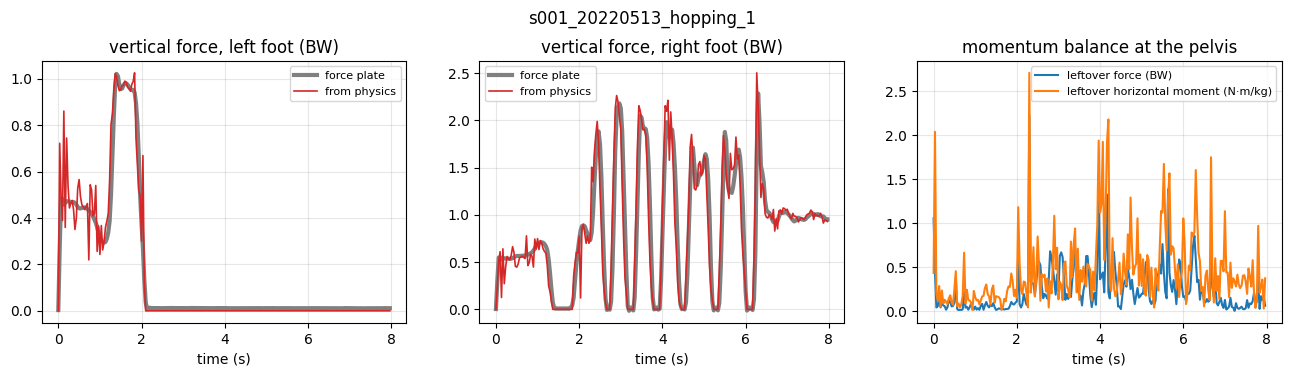

In [14]:
def physics_grf(d, con):
    """Per-foot force (n,2,3) in body weights and the zero-moment point (n,2), from whole-body motion and contact flags (n,2)."""
    Ft = (d['acom'] - GV) / G_ACC; H = d['Hdot'] / G_ACC; rz = d['z0'] - d['com'][:, 2]; Fz = np.maximum(Ft[:, 2], 1e-3)
    zmp = d['com'][:, :2] + np.stack([(rz * Ft[:, 0] - H[:, 1]) / Fz, (H[:, 0] + rz * Ft[:, 1]) / Fz], 1)
    fL, fR = d['feet'][:, 0, :2], d['feet'][:, 1, :2]; dv = fL - fR
    w = np.clip(((zmp - fR) * dv).sum(1) / np.maximum((dv ** 2).sum(1), 1e-6), 0, 1); wL = np.where(con[:, 0] & con[:, 1], w, con[:, 0].astype(float))
    Fp = np.stack([wL[:, None] * Ft, (1 - wL)[:, None] * Ft], 1); Fp[~con.any(1)] = 0
    return Fp, zmp, Ft

def grf_eval(con_fn):
    e_foot, e_tot, e_zmp, viol = [], [], [], np.zeros(5)
    for d in trials:
        v = d['valid']; con = con_fn(d); Fp, zmp, Ft = physics_grf(d, con); meas = d['grf']
        e_foot.append((Fp[v, :, 2] - meas[v, :, 2]).ravel()); e_tot.append(Ft[v, 2] - meas[v, :, 2].sum(1))
        ld = v & (meas[:, :, 2].sum(1) > 0.3); mc = (d['cop'][:, :, :2] * meas[:, :, 2:3]).sum(1) / np.maximum(meas[:, :, 2:3].sum(1), 1e-6)   # measured overall centre of pressure
        e_zmp.append(np.linalg.norm(zmp[ld] - mc[ld], axis=1)); anyc = con.any(1)
        dfoot = np.linalg.norm(zmp[:, None] - d['feet'][:, :, :2], axis=-1).min(1)
        viol += [v.sum(), (v & (Ft[:, 2] < 0)).sum(), (v & anyc & (np.linalg.norm(Ft[:, :2], axis=1) > MU_FRICTION * np.maximum(Ft[:, 2], 0))).sum(),
                 (v & ~anyc & (np.linalg.norm(Ft, axis=1) > 0.2)).sum(), (v & anyc & ~(con[:, 0] & con[:, 1]) & (dfoot > 0.20)).sum()]
    rms = lambda x: float(np.sqrt(np.mean(np.concatenate(x) ** 2)))
    return {'vertical force per foot, RMSE (BW)': rms(e_foot), 'total vertical force, RMSE (BW)': rms(e_tot), 'zero-moment point vs measured CoP, median (cm)': 100 * float(np.median(np.concatenate(e_zmp))),
            'frames needing a pulling force (%)': 100 * viol[1] / viol[0], 'frames outside the friction cone (%)': 100 * viol[2] / viol[0],
            'no contact but force > 0.2 BW (%)': 100 * viol[3] / viol[0], 'single support, ZMP > 20 cm from the foot (%)': 100 * viol[4] / viol[0]}
con_measured = lambda d: d['grf'][:, :, 2] > 0.05
con_motion = lambda d: (d['sole_h'] < 0.05) & (d['sole_v'] < 0.5)
agree = np.mean(np.concatenate([(con_measured(d) == con_motion(d))[d['valid']].ravel() for d in trials]))
half = lambda d: np.ones_like(d['grf'][:, :, 2], dtype=bool)                               # baseline: both feet always down
phys_tab = pd.DataFrame({'physics, measured contact': grf_eval(con_measured), 'physics, contact from motion': grf_eval(con_motion), 'physics, both feet always down': grf_eval(half)}).round(3)
phys_tab.to_csv(f'{WORK_DIR}/results/physics_grf.csv'); print('contact from motion agrees with measured contact on %.1f%% of feet' % (100 * agree)); display(phys_tab)

d0 = next((d for m_ in ('hopping', 'jumpingjack', 'balletsmalljump', 'squat') for d in trials if d['motion'] == m_), trials[0])   # one trial as a picture
Fp, zmp, Ft = physics_grf(d0, con_measured(d0)); tt = np.arange(len(Ft)) / FPS; sl = slice(0, min(len(tt), 8 * FPS))
fig, ax = plt.subplots(1, 3, figsize=(16, 3.4))
for k, lab in enumerate(['left', 'right']): ax[k].plot(tt[sl], d0['grf'][sl, k, 2], '0.5', lw=3, label='force plate'); ax[k].plot(tt[sl], Fp[sl, k, 2], 'C3', lw=1.2, label='from physics'); ax[k].set_title(f'vertical force, {lab} foot (BW)')
ax[2].plot(tt[sl], d0['resF'][sl] / G_ACC, label='leftover force (BW)'); ax[2].plot(tt[sl], d0['resM'][sl], label='leftover horizontal moment (N·m/kg)'); ax[2].set_title('momentum balance at the pelvis')
for a in ax: a.set_xlabel('time (s)'); a.legend(fontsize=8); a.grid(alpha=.3)
plt.suptitle(d0['name'], y=1.03); plt.savefig(f'{WORK_DIR}/results/physics_grf_example.png', dpi=150, bbox_inches='tight'); plt.show()

164 trials refined  (585s)


,root error (cm),"total force error, RMSE (BW)","force during flight, mean (BW; should be 0)"
corrupted,5.709,0.305,0.291
smoothing only,5.702,0.268,0.258
smoothing + contact,5.415,0.205,0.346
smoothing + contact + dynamics,6.022,0.177,0.187
true root (reference),0.000,0.085,0.090


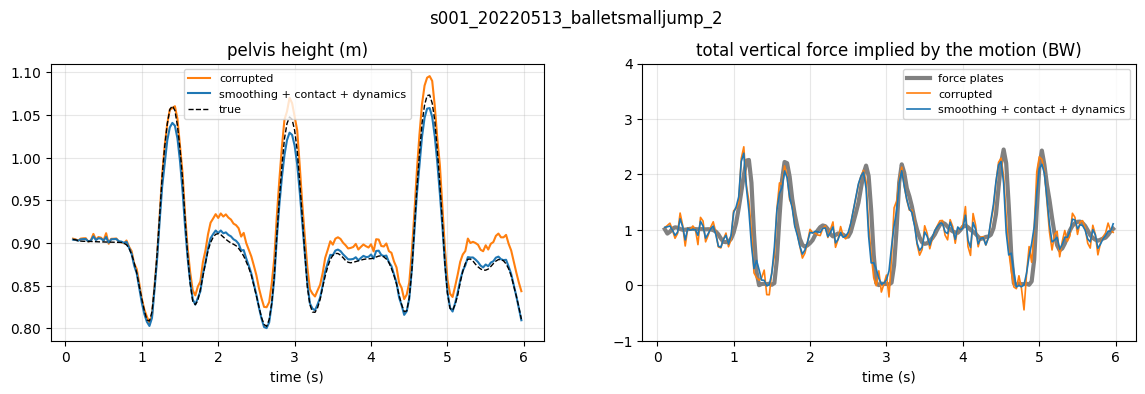

In [15]:
REF_W = dict(pos=0.01, vel=0.05, jerk=2e-6, slide=1.0, height=20.0, pen=100.0, fly=2e-3, pull=2e-3, fric=2e-3)       # starting weights, not tuned
DYN_MOTIONS = ['hopping', 'jumpingjack', 'balletsmalljump', 'squat', 'lambadadance', 'soccerkick', 'tennisserve', 'tennisgroundstroke', 'walk', 'walk_00', 'taichi']

def corrupt_root(pel, seed):
    g = torch.Generator().manual_seed(seed); n = len(pel)
    d = torch.cumsum(torch.randn(3, n, generator=g), -1); d = F.avg_pool1d(F.pad(d[None], (7, 7), mode='replicate'), 15, 1)[0]; d = d - d[:, :1]
    return pel + (d / d.norm(dim=0).max() * 0.10).T + torch.randn(n, 3, generator=g) * 0.003

def refine(d, r_obs, use=('contact', 'dynamics'), steps=300):
    t32 = lambda x: torch.tensor(x, dtype=torch.float32, device=dev); dt = 1.0 / FPS; gv = t32(GV)
    qcom, qfeet, c, z0 = t32(d['com'] - d['pel']), t32(d['feet'] - d['pel'][:, None]), t32(d['grf'][:, :, 2] > 0.05), d['z0']
    qlow = t32(d['sole_h'] + d['z0'] - d['pel'][:, 2:3])                                    # lowest sole point of each foot, relative to the pelvis
    r_obs = r_obs.to(dev); v_obs = torch.cat([torch.zeros(1, 3, device=dev), (r_obs[1:] - r_obs[:-1]) / dt])
    v = v_obs.clone().requires_grad_(True); r0 = torch.zeros(3, device=dev, requires_grad=True)      # optimise velocity and a starting offset, integrate to get the path
    opt = torch.optim.Adam([v, r0], lr=0.02); sched = torch.optim.lr_scheduler.LambdaLR(opt, lambda k: 1 - k / steps); path = lambda: r_obs[0] + r0 + torch.cumsum(v, 0) * dt
    for _ in range(steps):
        r = path()
        com = r + qcom; a = (com[2:] - 2 * com[1:-1] + com[:-2]) / dt ** 2; feet = r[:, None] + qfeet; vf = (feet[1:] - feet[:-1]) / dt; anyc = c.max(1).values[1:-1]; low = r[:, 2:3] + qlow
        loss = REF_W['pos'] * ((r - r_obs) ** 2).sum(-1).mean() + REF_W['vel'] * ((v - v_obs) ** 2).sum(-1).mean() + REF_W['jerk'] * ((a[1:] - a[:-1]) ** 2).sum(-1).mean()
        if 'contact' in use:
            loss = loss + REF_W['slide'] * (c[1:, :, None] * vf ** 2).sum(-1).mean() + REF_W['height'] * (c * (low - z0) ** 2).mean() + REF_W['pen'] * torch.relu(z0 - 0.02 - low).pow(2).mean()
        if 'dynamics' in use:
            up = a[:, 2] + G_ACC
            loss = loss + REF_W['fly'] * ((1 - anyc)[:, None] * (a - gv) ** 2).sum(-1).mean() + REF_W['pull'] * (anyc * torch.relu(-up) ** 2).mean() \
                        + REF_W['fric'] * (anyc * torch.relu(a[:, :2].norm(dim=-1) - MU_FRICTION * up.clamp_min(0)) ** 2).mean()
        opt.zero_grad(); loss.backward(); opt.step(); sched.step()
    return path().detach().cpu()

def refine_score(d, r):
    pel = torch.tensor(d['pel']); com = (r + torch.tensor(d['com'] - d['pel'])).numpy(); Ft = (np.gradient(np.gradient(com, 1 / FPS, axis=0), 1 / FPS, axis=0) - GV) / G_ACC
    v = d['valid'].copy(); v[:3] = v[-3:] = False; tot = d['grf'].sum(1); fly = v & (tot[:, 2] < 0.05)
    return np.array([(r - pel).norm(dim=-1).mean().item() * 100, ((Ft[v] - tot[v]) ** 2).sum(-1).sum(), v.sum(), np.linalg.norm(Ft[fly], axis=1).sum(), fly.sum()])

VERSIONS = {'corrupted': None, 'smoothing only': (), 'smoothing + contact': ('contact',), 'smoothing + contact + dynamics': ('contact', 'dynamics')}
acc = {k: [] for k in VERSIONS}; acc['true root (reference)'] = []; sel = [d for d in trials if d['motion'] in DYN_MOTIONS and len(d['pel']) >= 60]; t0 = time.time(); keep_ex = None
for i, d in enumerate(sel):
    r_obs = corrupt_root(torch.tensor(d['pel']), i); outs = {k: (r_obs if u is None else refine(d, r_obs, u)) for k, u in VERSIONS.items()}; outs['true root (reference)'] = torch.tensor(d['pel'])
    for k, r in outs.items(): acc[k].append(refine_score(d, r))
    if keep_ex is None and d['motion'] in ('hopping', 'jumpingjack', 'balletsmalljump'): keep_ex = (d, outs)
print(f'{len(sel)} trials refined  ({time.time() - t0:.0f}s)')
def summarise(a):
    a = np.array(a); return {'root error (cm)': a[:, 0].mean(), 'total force error, RMSE (BW)': np.sqrt(a[:, 1].sum() / a[:, 2].sum()), 'force during flight, mean (BW; should be 0)': a[:, 3].sum() / max(a[:, 4].sum(), 1)}
ref_tab = pd.DataFrame({k: summarise(v) for k, v in acc.items()}).T.round(3); ref_tab.to_csv(f'{WORK_DIR}/results/refinement.csv'); display(ref_tab)
if keep_ex is not None:
    d, outs = keep_ex; tt = np.arange(len(d['pel'])) / FPS; sl = slice(3, min(len(tt), 6 * FPS)); fig, ax = plt.subplots(1, 2, figsize=(14, 3.6))
    ax[1].plot(tt[sl], d['grf'].sum(1)[sl, 2], '0.5', lw=3, label='force plates')
    for k, col in [('corrupted', 'C1'), ('smoothing + contact + dynamics', 'C0')]:
        r = outs[k]; com = (r + torch.tensor(d['com'] - d['pel'])).numpy(); Fz = np.gradient(np.gradient(com[:, 2], 1 / FPS), 1 / FPS) / G_ACC + 1
        ax[0].plot(tt[sl], r[sl, 2], col, label=k); ax[1].plot(tt[sl], Fz[sl], col, lw=1.2, label=k)
    ax[0].plot(tt[sl], d['pel'][sl, 2], 'k--', lw=1, label='true'); ax[0].set_title('pelvis height (m)'); ax[1].set_title('total vertical force implied by the motion (BW)'); ax[1].set_ylim(-1, 4)
    for a_ in ax: a_.set_xlabel('time (s)'); a_.legend(fontsize=8); a_.grid(alpha=.3)
    plt.suptitle(d['name'], y=1.03); plt.savefig(f'{WORK_DIR}/results/refinement_example.png', dpi=150, bbox_inches='tight'); plt.show()

In [16]:
class TBlock(nn.Module):
    def __init__(self, d, k, dil, causal):
        super().__init__(); self.pad = (dil * (k - 1), 0) if causal else (dil * (k // 2), dil * (k // 2)); self.c = nn.Conv1d(d, d, k, dilation=dil); self.n = nn.LayerNorm(d)
    def forward(self, x): return x + F.gelu(self.n(self.c(F.pad(x, self.pad)).transpose(1, 2)).transpose(1, 2))
class Tracker(nn.Module):
    def __init__(self, dim=3, mode='offline', d=256):
        super().__init__(); k = 1 if mode == 'frame' else 3; self.inp = nn.Conv1d(22 * (dim + 1), d, 1)
        self.body = nn.Sequential(*[TBlock(d, k, dil if k > 1 else 1, mode == 'causal') for dil in (1, 2, 4, 8, 16)]); self.rot, self.con = nn.Conv1d(d, 22 * 6, 1), nn.Conv1d(d, 4, 1)
    def forward(self, obs, m):
        h = self.body(self.inp(torch.cat([obs * m[..., None], m[..., None]], -1).flatten(2).transpose(1, 2))); x = self.rot(h).transpose(1, 2).reshape(*obs.shape[:2], 22, 6)
        b1 = F.normalize(x[..., :3], dim=-1); b2 = F.normalize(x[..., 3:] - (b1 * x[..., 3:]).sum(-1, keepdim=True) * b1, dim=-1)
        return torch.stack([b1, b2, torch.cross(b1, b2, dim=-1)], -1), self.con(h).transpose(1, 2)

def state30(d, rel, G):                                # segment kinematics at 30 Hz from pelvis-relative joints (unscaled) and global rotations
    st = body_state(rel.astype(np.float64), G.astype(np.float64), d['pel'].astype(np.float64), d['scale'], BSP[d['gender']], FPS)
    return {**d, 'com': st['com'], 'acom': st['acom'], 'Hdot': st['Hdot']}

if os.path.exists(TRACKER_CKPT):
    trk = Tracker().to(dev); trk.load_state_dict(torch.load(TRACKER_CKPT, map_location=dev)); trk.eval(); err = {'true pose, 30 Hz': [], 'tracked pose': []}; je = []
    for i, d in enumerate(trials):
        n = len(d['rel'])
        if n < 96: continue
        Jm = (REF.Jr @ REF.vt); off = torch.stack([Jm[k] - Jm[PAR[k]] if k else torch.zeros(3, device=dev) for k in range(22)])[None]
        torch.manual_seed(i); x = torch.tensor(d['rel'], device=dev)[None]; m = torch.ones(1, n, 22, device=dev)
        for s0 in range(30, n - 30, 90): m[:, s0:s0 + 30, [1, 4, 7, 10]] = 0
        with torch.no_grad():
            R, _ = trk(x + torch.randn_like(x) * 0.015, m); Gs, P = [R[:, :, 0]], [torch.zeros(1, n, 3, device=dev)]
            for k in range(1, 22): p = PAR[k]; Gs.append(Gs[p] @ R[:, :, k]); P.append(P[p] + (Gs[p] @ off[:, None, k, :, None]).squeeze(-1))
        relh, Gh = torch.stack(P, 2)[0].cpu().numpy(), torch.stack(Gs, 2)[0].cpu().numpy(); je.append(1000 * np.linalg.norm(relh - d['rel'], axis=-1).mean())
        v = d['valid'].copy(); v[:5] = v[-5:] = False; con = con_measured(d)
        for k, (rl, Gg) in {'true pose, 30 Hz': (d['rel'], d['G']), 'tracked pose': (relh, Gh)}.items():
            Fp, _, Ft = physics_grf(state30(d, rl, Gg), con); err[k].append(np.stack([((Fp[v, :, 2] - d['grf'][v, :, 2]) ** 2).sum(), 2 * v.sum(), ((Ft[v, 2] - d['grf'][v, :, 2].sum(1)) ** 2).sum(), v.sum()]))
    ch = {k: {'vertical force per foot, RMSE (BW)': np.sqrt(np.array(e)[:, 0].sum() / np.array(e)[:, 1].sum()), 'total vertical force, RMSE (BW)': np.sqrt(np.array(e)[:, 2].sum() / np.array(e)[:, 3].sum())} for k, e in err.items()}
    print('tracker joint error on GroundLink motion: %.1f mm (noise 15 mm, left leg hidden one second in three)' % np.mean(je))
    chain_tab = pd.DataFrame(ch).T.round(3); chain_tab.to_csv(f'{WORK_DIR}/results/tracker_chain.csv'); display(chain_tab)
else: print('No tracker weights at', TRACKER_CKPT, '- skipping this optional section.')

tracker joint error on GroundLink motion: 36.1 mm (noise 15 mm, left leg hidden one second in three)


,"vertical force per foot, RMSE (BW)","total vertical force, RMSE (BW)"
"true pose, 30 Hz",0.052,0.046
tracked pose,0.060,0.048


In [17]:
HY_T, HY_STRIDE, HY_EPOCHS, HY_BATCH, HY_LR = 64, 16, 60, 256, 1e-3

class Block(nn.Module):
    def __init__(self, d, k, dil):
        super().__init__(); self.c = nn.Conv1d(d, d, k, padding=dil * (k // 2), dilation=dil); self.n = nn.GroupNorm(8, d)
    def forward(self, x): return x + F.gelu(self.n(self.c(x)))

def hy_windows(d):
    n = len(d['rel']); st = list(range(0, n - HY_T + 1, HY_STRIDE))
    if not st: return None
    Fa, zmp, Ft = physics_grf(d, con_measured(d)); Fb, _, _ = physics_grf(d, con_motion(d))
    arr = [d['rel'], d['grf'].reshape(n, 6), d['valid'].astype(np.float32), Ft.astype(np.float32), (zmp[:, None] - d['feet'][:, :, :2]).reshape(n, 4).astype(np.float32),
           Fa.reshape(n, 6).astype(np.float32), Fb.reshape(n, 6).astype(np.float32)]
    return [torch.tensor(np.stack([a[s:s + HY_T] for s in st])) for a in arr]
HW = {}
for s in sorted(gl_cal):
    w = [x for x in (hy_windows(d) for d in trials if d['subj'] == s and d['motion'] != 'dog') if x is not None]
    if w: HW[s] = dict(zip(['X', 'Y', 'V', 'FT', 'Z', 'PA', 'PB'], [torch.cat([x[i] for x in w]).to(dev) for i in range(7)]))
subs = list(HW)
print({s: len(HW[s]['X']) for s in subs}, 'clips per subject')

class SplitNet(nn.Module):
    def __init__(self, mode, d=256):                   # mode: 'direct', 'hybrid' or 'hybrid+physics'
        super().__init__(); self.mode = mode
        self.inp = nn.Conv1d(22 * 6 + (7 if mode == 'hybrid+physics' else 0), d, 1); self.body = nn.Sequential(*[Block(d, 3, dil) for dil in (1, 2, 4, 8)])
        self.head = nn.Conv1d(d, 6 if mode == 'direct' else 3, 1)
    def forward(self, x, ft, z):                       # joints (B,T,22,3), physics total force (B,T,3), zero-moment point relative to each foot (B,T,4) -> per-foot forces (B,T,6)
        vel = torch.zeros_like(x); vel[:, 1:] = (x[:, 1:] - x[:, :-1]) * FPS; vel[:, 0] = vel[:, 1]; f = torch.cat([x, vel], -1).flatten(2)
        if self.mode == 'hybrid+physics': f = torch.cat([f, ft, z.clamp(-2, 2)], -1)
        o = self.head(self.body(self.inp(f.transpose(1, 2)))).transpose(1, 2)
        if self.mode == 'direct': return o
        w, h = torch.sigmoid(o[..., :1]), 0.1 * o[..., 1:3]; fz = ft[..., 2:].clamp_min(0)                    # share on the left foot; opposing horizontal pair; the ground cannot pull
        return torch.cat([w * ft[..., :2] + h, w * fz, (1 - w) * ft[..., :2] - h, (1 - w) * fz], -1)

def rot_batch(B):
    a = torch.rand(B, device=dev) * 2 * np.pi; c, s, z, o = a.cos(), a.sin(), torch.zeros(B, device=dev), torch.ones(B, device=dev)
    return torch.stack([c, -s, z, s, c, z, z, z, o], -1).view(B, 3, 3)

def hy_fit(d, mode):
    torch.manual_seed(SEED); model = SplitNet(mode).to(dev); n = len(d['X']); opt = torch.optim.AdamW(model.parameters(), lr=HY_LR, weight_decay=1e-3)
    sched = torch.optim.lr_scheduler.OneCycleLR(opt, HY_LR, total_steps=HY_EPOCHS * ((n + HY_BATCH - 1) // HY_BATCH))
    for ep in range(HY_EPOCHS):
        model.train(); perm = torch.randperm(n, device=dev)
        for i in range(0, n, HY_BATCH):
            b = perm[i:i + HY_BATCH]; R = rot_batch(len(b)); r3 = lambda v: torch.einsum('bij,bt...j->bt...i', R, v); r2 = lambda v: torch.einsum('bij,bt...j->bt...i', R[:, :2, :2], v)
            x, y, ft = r3(d['X'][b]), r3(d['Y'][b].view(len(b), HY_T, 2, 3)).reshape(len(b), HY_T, 6), r3(d['FT'][b]); z = r2(d['Z'][b].view(len(b), HY_T, 2, 2)).reshape(len(b), HY_T, 4)
            loss = (F.smooth_l1_loss(model(x, ft, z), y, reduction='none', beta=0.1).mean(-1) * d['V'][b]).sum() / d['V'][b].sum().clamp_min(1)
            opt.zero_grad(); loss.backward(); nn.utils.clip_grad_norm_(model.parameters(), 1.0); opt.step(); sched.step()
    return model.eval()

def hy_score(pred, d):
    v = d['V'] > 0.5; P, Y = pred[v].view(-1, 2, 3), d['Y'][v].view(-1, 2, 3)
    return {'vertical force per foot, RMSE (BW)': (P[..., 2] - Y[..., 2]).pow(2).mean().sqrt().item(), '3D force per foot, RMSE (BW)': (P - Y).pow(2).sum(-1).mean().sqrt().item(),
            'total vertical force, RMSE (BW)': (P[..., 2].sum(1) - Y[..., 2].sum(1)).pow(2).mean().sqrt().item()}

LEARNED = {'network, direct (no physics)': 'direct', 'hybrid: physics total + learned split': 'hybrid', 'hybrid + physics quantities as input': 'hybrid+physics'}
hy, t0 = {}, time.time()
for s in subs:
    trn = {k: torch.cat([HW[o][k] for o in subs if o != s]) for k in HW[s]}; tst = HW[s]
    hy[(s, 'physics rule, measured contact (upper bound)')] = hy_score(tst['PA'], tst); hy[(s, 'physics rule, contact from motion')] = hy_score(tst['PB'], tst)
    for name, mode in LEARNED.items():
        model = hy_fit(trn, mode)
        with torch.no_grad(): hy[(s, name)] = hy_score(torch.cat([model(tst['X'][i:i + 1024], tst['FT'][i:i + 1024], tst['Z'][i:i + 1024]) for i in range(0, len(tst['X']), 1024)]), tst)
    print(f'held out {s}  ({time.time() - t0:.0f}s)')
hd = pd.DataFrame(hy).T.astype(float); hd.index.names = ['subject', 'method']; hd.to_csv(f'{WORK_DIR}/results/hybrid_all.csv')
ORDER = ['physics rule, measured contact (upper bound)', 'physics rule, contact from motion', *LEARNED]; g = hd.groupby(level='method')
print('Mean ± standard deviation over the', len(subs), 'held-out subjects:'); display((g.mean().round(3).astype(str) + ' ± ' + g.std().round(3).astype(str)).loc[ORDER])
c0 = 'vertical force per foot, RMSE (BW)'; hyb = hd.xs('hybrid: physics total + learned split', level='method')[c0]
for other in ['network, direct (no physics)', 'physics rule, contact from motion', 'physics rule, measured contact (upper bound)']:
    print(f'hybrid beats "{other}" on per-foot vertical force for {int((hyb < hd.xs(other, level="method")[c0]).sum())} of {len(subs)} subjects')
print('Per held-out subject, per-foot vertical force RMSE (BW):'); display(hd[c0].unstack()[ORDER].round(3))

{'s001': 1171, 's002': 1213, 's003': 1600, 's004': 1050, 's005': 1244, 's006': 1448, 's007': 874} clips per subject
held out s001  (41s)
held out s002  (81s)
held out s003  (119s)
held out s004  (160s)
held out s005  (200s)
held out s006  (239s)
held out s007  (281s)
Mean ± standard deviation over the 7 held-out subjects:


,"vertical force per foot, RMSE (BW)","3D force per foot, RMSE (BW)","total vertical force, RMSE (BW)"
method,,,
"physics rule, measured contact (upper bound)",0.079 ± 0.013,0.11 ± 0.017,0.045 ± 0.005
"physics rule, contact from motion",0.09 ± 0.022,0.118 ± 0.027,0.045 ± 0.005
"network, direct (no physics)",0.072 ± 0.027,0.079 ± 0.027,0.064 ± 0.015
hybrid: physics total + learned split,0.059 ± 0.025,0.074 ± 0.023,0.045 ± 0.004
hybrid + physics quantities as input,0.056 ± 0.024,0.07 ± 0.022,0.045 ± 0.004


hybrid beats "network, direct (no physics)" on per-foot vertical force for 7 of 7 subjects
hybrid beats "physics rule, contact from motion" on per-foot vertical force for 7 of 7 subjects
hybrid beats "physics rule, measured contact (upper bound)" on per-foot vertical force for 6 of 7 subjects
Per held-out subject, per-foot vertical force RMSE (BW):


method,"physics rule, measured contact (upper bound)","physics rule, contact from motion","network, direct (no physics)",hybrid: physics total + learned split,hybrid + physics quantities as input
subject,,,,,
s001,0.075,0.126,0.129,0.113,0.109
s002,0.072,0.074,0.057,0.043,0.044
s003,0.083,0.089,0.057,0.052,0.051
s004,0.076,0.078,0.056,0.046,0.044
s005,0.057,0.061,0.078,0.056,0.047
s006,0.096,0.107,0.071,0.061,0.055
s007,0.095,0.095,0.053,0.044,0.044
